## Case Study: Data Download
This cell downloads the dataset from Kaggle Hub. The `kagglehub.dataset_download` function retrieves the specified dataset ('yasserh/customer-segmentation-dataset') and stores it locally. The `print` statement then shows the local path where the dataset files are located.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/customer-segmentation-dataset")

print("Path to dataset files:", path)

100%|██████████| 21.8M/21.8M [00:00<00:00, 79.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/yasserh/customer-segmentation-dataset/versions/1


## Case Study: Import Libraries
This cell imports essential Python libraries: `pandas` for data manipulation and `numpy` for numerical operations. These libraries are foundational for most data science workflows.

In [2]:
import pandas as pd
import numpy as np


## Case Study: Extract and Load Data
This cell handles the extraction of the dataset from a ZIP file and loads the main data into a pandas DataFrame. It first creates a directory for extraction, then unzips the `Online Retail.xlsx.zip` file. After extraction, it iterates through the extracted files to find the `.xlsx` file and loads it into a DataFrame named `df` using `pd.read_excel`. Error handling is included to ensure the `.xlsx` file is found.

In [7]:
import zipfile
import os

zip_path = '/content/Online Retail.xlsx.zip'
extract_dir = '/content/extracted_data'

# Create a directory for extraction if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Find the .xlsx file in the extracted directory
excel_file_name = None
for file in os.listdir(extract_dir):
    if file.endswith('.xlsx'):
        excel_file_name = file
        break

if excel_file_name:
    excel_file_path = os.path.join(extract_dir, excel_file_name)
    df = pd.read_excel(excel_file_path, engine='openpyxl')
    print(f"Successfully loaded {excel_file_name}")
else:
    raise FileNotFoundError("No .xlsx file found in the extracted archive.")

Successfully loaded Online Retail.xlsx


## Case Study: Display First 5 Rows
This cell displays the first 5 rows of the loaded DataFrame (`df`). This is a common and quick way to inspect the structure and content of the data, helping to understand the columns and their initial values.

In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Case Study: Display DataFrame Information
This cell uses the `df.info()` method to print a concise summary of the DataFrame. This includes the index dtype and column dtypes, non-null values, and memory usage. It's crucial for understanding data types and identifying columns with missing values.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## Case Study: Check for Missing Values
This cell calculates and displays the number of missing values (NaNs) in each column of the DataFrame. `df.isnull().sum()` is a quick way to identify which columns have missing data and quantify their extent, guiding further data cleaning steps.

In [10]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


## Case Study: Drop CustomerID Column
This cell removes the 'CustomerID' column from the DataFrame. The 'CustomerID' column had a significant number of missing values (as seen in the previous `isnull().sum()` output), and for the purpose of this analysis, it might be decided to drop it rather than impute it, potentially simplifying the dataset.

In [11]:
df = df.drop(columns=['CustomerID'])

## Case Study: Impute Missing Descriptions
This cell handles missing values in the 'Description' column by imputing them with the most frequent description. It first finds the mode (most frequent item) of the 'Description' column and then uses `fillna()` to replace all NaN values with this mode. This approach assumes that the most common description is a reasonable substitute for missing product descriptions.

In [12]:

# Mode returns a list/series, so we use [0] to grab the top most frequent item
most_frequent_item = df['Description'].mode()[0]

# Fill the missing descriptions
df['Description'] = df['Description'].fillna(most_frequent_item)


## Case Study: Verify No Missing Values
This cell re-checks for missing values after the imputation steps. `df.isnull().sum()` is used again to confirm that all missing values in 'Description' and 'CustomerID' (which was dropped) have been successfully addressed, ensuring a clean dataset for further analysis.

In [13]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0


## Case Study: Data Cleaning and Feature Engineering (Initial)
This cell performs several crucial data cleaning and initial feature engineering steps. It imports additional libraries for plotting and clustering, converts 'InvoiceDate' to datetime objects, calculates 'TotalSpend' for each transaction, and filters out rows with non-positive 'Quantity' or 'UnitPrice' to ensure valid transactional data. The `df_cleaned.head()` displays the updated DataFrame.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Date ko datetime format mein badlein
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 2. Total Spend calculate karein (Quantity * UnitPrice)
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

# 3. Sahi rows filter karein (Quantity aur Price dono positive honi chahiye)
df_cleaned = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

print("Cleaned Data Shape:", df_cleaned.shape)
df_cleaned.head()


Cleaned Data Shape: (530104, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country,TotalSpend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34


## Case Study: RFM Feature Engineering (Invoice Level)
This cell engineers RFM (Recency, Frequency, Monetary) features at the invoice level. It sets a `snapshot_date` to calculate Recency (days since last purchase), counts `StockCode` for Frequency (number of items per invoice), and sums `TotalSpend` for Monetary value. The resulting `invoice_df` provides a transactional view of RFM metrics.

In [15]:
# Ek reference date banayein recency calculate karne ke liye
snapshot_date = df_cleaned['InvoiceDate'].max() + pd.Timedelta(days=1)

# InvoiceNo ke basis par group karein
invoice_df = df_cleaned.groupby('InvoiceNo').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'StockCode': 'count',                                   # Frequency
    'TotalSpend': 'sum'                                     # Monetary
}).reset_index()

# Columns ke naam rename karein
invoice_df.columns = ['InvoiceNo', 'Recency', 'Frequency', 'Monetary']

print("Engineered Invoice DataFrame:")
invoice_df.head()


Engineered Invoice DataFrame:


,InvoiceNo,Recency,Frequency,Monetary
0,536365,374,7,139.12
1,536366,374,2,22.20
2,536367,374,12,278.73
3,536368,374,4,70.05
4,536369,374,1,17.85


## Case Study: Data Transformation and Scaling
This cell prepares the RFM features for clustering. It first applies a log transformation (`np.log1p`) to 'Recency', 'Frequency', and 'Monetary' to reduce skewness and handle extreme values. Then, it uses `StandardScaler` to scale these features, ensuring they have a mean of 0 and a variance of 1. This standardization is critical for KMeans, which is sensitive to feature scales.

In [16]:
# 1. Log transformation lagayein skewness hatane ke liye
X_raw = invoice_df[['Recency', 'Frequency', 'Monetary']]
X_log = np.log1p(X_raw)

# 2. Scale karein (Mean = 0, Variance = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# DataFrame format mein save karein
X_scaled_df = pd.DataFrame(X_scaled, columns=['Recency_Scaled', 'Frequency_Scaled', 'Monetary_Scaled'])
X_scaled_df.head()


,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
0,1.114228,-0.570517,-0.523439
1,1.114228,-1.469764,-2.015115
2,1.114228,-0.125392,0.049995
3,1.114228,-1.001427,-1.086745
4,1.114228,-1.841504,-2.187346


## Case Study: Elbow Method for Optimal K
This cell implements the Elbow Method to determine the optimal number of clusters (K) for KMeans. It calculates the Within-Cluster Sum of Squares (WCSS) for a range of K values (1 to 10). The plot of WCSS vs. K helps visually identify the 'elbow point,' where the rate of decrease in WCSS significantly slows down, suggesting an appropriate K.

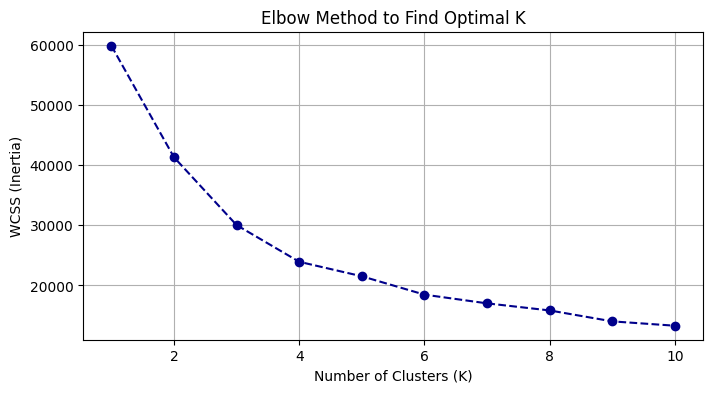

In [17]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='darkblue')
plt.title('Elbow Method to Find Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()


## Case Study: K-Means Clustering Application
This cell applies the K-Means clustering algorithm using the `optimal_k` (determined from the Elbow Method, here set to 4). It fits the model to the scaled RFM data and assigns a 'Cluster' label to each invoice in the `invoice_df`. The cluster labels are converted to strings for plotting, and the distribution of invoices across clusters is printed.

In [18]:
# Model initialize aur fit karein
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)

# Cluster labels ko main dataframe mein add karein
invoice_df['Cluster'] = kmeans.fit_predict(X_scaled)

# String type mein convert karein plotting ke liye
invoice_df['Cluster'] = invoice_df['Cluster'].astype(str)

print("Cluster Distribution:")
print(invoice_df['Cluster'].value_counts())


Cluster Distribution:
Cluster
0    8560
1    5032
3    3860
2    2508
Name: count, dtype: int64


## Case Study: Interactive 3D Cluster Visualization
This cell generates an interactive 3D scatter plot using Plotly Express to visualize the K-Means clusters in the Recency, Frequency, and Monetary (RFM) space. Each point represents an invoice, colored by its assigned cluster. Logarithmic scales are applied to the axes to handle the wide range of values and improve visualization clarity. This plot helps understand the spatial separation of the clusters.

In [19]:
# Plotly interactive 3D Scatter Plot
fig = px.scatter_3d(
    invoice_df,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='Cluster',
    log_x=True, # Log scale use kar rahe hain takki graph clean dikhe
    log_y=True,
    log_z=True,
    opacity=0.7,
    title='Interactive 3D K-Means Clusters (RFM Space)',
    labels={'Recency': 'Recency (Days)', 'Frequency': 'Frequency (Items Count)', 'Monetary': 'Monetary (Total Bill)'},
    color_discrete_sequence=px.colors.qualitative.Set1
)

# Graph layout updates
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()


## Case Study: Business Metrics per Cluster
This cell calculates the average 'Recency', 'Frequency', and 'Monetary' values for each cluster. This 'profile' helps in understanding the distinct characteristics of each customer segment identified by the clustering algorithm, providing insights into their purchasing behavior.

In [20]:
# Har cluster ka raw business averages check karein
profile = invoice_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print("=== BUSINESS METRICS PER CLUSTER ===")
print(profile)


=== BUSINESS METRICS PER CLUSTER ===
            Recency  Frequency     Monetary
Cluster                                    
0        215.495911  13.060047   321.535527
1        177.651033  64.943561  1203.199980
2        172.769139   2.374402    46.533641
3         24.412435  22.165544   451.588539


## Case Study: Detailed Business Persona Breakdown
This cell provides a more detailed breakdown of each cluster's RFM metrics, including mean, minimum, and maximum values for Recency, Frequency, and Monetary. It also counts the number of invoices in each cluster. This granular summary aids in defining specific business personas for each segment, which can inform targeted marketing strategies.

In [21]:
# Har cluster ki detailed operational metrics nikalen
cluster_summary = invoice_df.groupby('Cluster').agg({
    'Recency': ['mean', 'min', 'max'],
    'Frequency': ['mean', 'min', 'max'],
    'Monetary': ['mean', 'min', 'max', 'count']
}).round(2)

print("=== DETAILED BUSINESS PERSONA BREAKDOWN ===")
print(cluster_summary)

# Business Logic to name the clusters dynamically based on your output:
# Cluster with lowest Recency & highest Monetary = "VIP / Champions"
# Cluster with highest Recency & lowest Frequency = "Lost / Hibernating"
# Cluster with high Frequency but low Monetary = "Bulk Low-Value Buyers"


=== DETAILED BUSINESS PERSONA BREAKDOWN ===
        Recency          Frequency           Monetary                         
           mean min  max      mean min   max     mean     min        max count
Cluster                                                                       
0        215.50  47  374     13.06   1    57   321.54   31.62   13541.33  8560
1        177.65   2  374     64.94   1  1114  1203.20  111.78   77183.60  5032
2        172.77   1  374      2.37   1    17    46.53    0.38     240.00  2508
3         24.41   1   66     22.17   1   731   451.59    6.31  168469.60  3860


## Case Study: Outlier Removal and Power Transformation (Refinement)
This cell refines the data preparation by first removing outliers using the Interquartile Range (IQR) method from the 'Recency', 'Frequency', and 'Monetary' features. After outlier removal, it applies a `PowerTransformer` (specifically the Yeo-Johnson method) to the features. This transformation aims to make the data more Gaussian-like, which can improve the performance of clustering algorithms. The cell also prints the number of rows before and after outlier removal.

In [22]:
from sklearn.preprocessing import PowerTransformer

# 1. IQR Method se Outliers ko remove karein (Extreme values completely clean karein)
def remove_outliers_iqr(df_in, columns):
    df_out = df_in.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Outliers ko filter karke range ke andar rakhein
        df_out = df_out[(df_out[col] >= lower_bound) & (df_out[col] <= upper_bound)]
    return df_out

# RFM data se outliers hatayein
invoice_df_clean = remove_outliers_iqr(invoice_df, ['Recency', 'Frequency', 'Monetary'])

# 2. PowerTransformer (Ye Yeo-Johnson transform use karta hai jo data ko perfect Gaussian/Normal distribution deta hai)
X_features = invoice_df_clean[['Recency', 'Frequency', 'Monetary']]
pt = PowerTransformer(method='yeo-johnson')
X_scaled = pt.fit_transform(X_features)

print("Original Data Rows:", len(invoice_df))
print("Data Rows after Outlier Removal:", len(invoice_df_clean))


Original Data Rows: 19960
Data Rows after Outlier Removal: 17144


## Case Study: Optimized K-Means Clustering
This cell re-applies K-Means clustering with an `optimal_k` of 3, based on potential optimization or re-evaluation after outlier removal and power transformation. It configures `n_init` (number of times the algorithm is run with different centroid seeds) and `max_iter` (maximum number of iterations for a single run) for more robust and optimized clustering. The cluster labels are then assigned to the `invoice_df_clean` DataFrame, and the `invoice_df` global variable is updated to reflect these cleaned clusters.

In [23]:
# K ko thoda optimize karein (agar 4 par score low hai toh k=3 check karein density ke liye)
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    n_init=20,          # 20 alag-alag random centroids se best starting point choose karega
    max_iter=500,       # Max iterations badha di taaki optimization perfect ho
    random_state=42
)

invoice_df_clean['Cluster'] = kmeans.fit_predict(X_scaled)
invoice_df_clean['Cluster'] = invoice_df_clean['Cluster'].astype(str)

# Global variables update karein taaki cell 6 aur cell 9 automatic clean run ho sakein
invoice_df = invoice_df_clean


## Case Study: Silhouette Analysis for Cluster Validation
This cell performs Silhouette analysis to evaluate the quality of the clustering. It calculates the `silhouette_score` for the entire model and `silhouette_samples` for each data point. The silhouette plot visualizes how well each point is assigned to its cluster, showing cluster separation and cohesion. A higher silhouette score indicates better-defined clusters.

Overall Model Silhouette Separation Score: 0.41


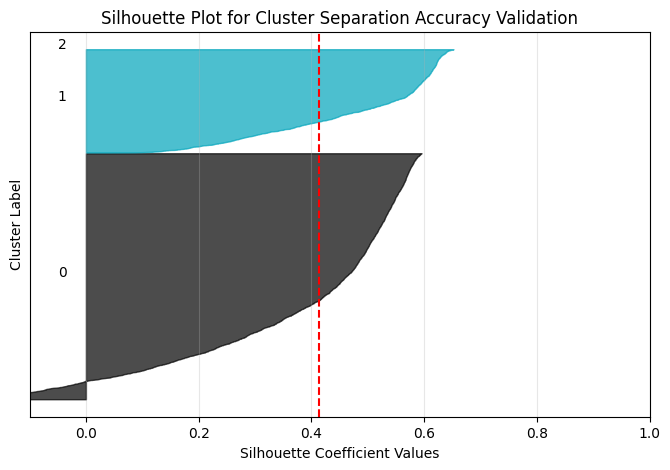

In [24]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

# Sample data small subset for plotting speed if dataset is huge (e.g., 5000 samples)
sample_size = min(5000, len(X_scaled))
X_sample = X_scaled[:sample_size]
labels_sample = kmeans.labels_[:sample_size]

silhouette_avg = silhouette_score(X_sample, labels_sample)
print(f"Overall Model Silhouette Separation Score: {silhouette_avg:.2f}")

# Compute the silhouette scores for each sample
sample_silhouette_values = silhouette_samples(X_sample, labels_sample)

fig, ax1 = plt.subplots(1, 1, figsize=(8, 5))
y_lower = 10

for i in range(optimal_k):
    # Ith cluster ke values sort karein
    ith_cluster_silhouette_values = sample_silhouette_values[labels_sample == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / optimal_k)
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax1.set_title("Silhouette Plot for Cluster Separation Accuracy Validation")
ax1.set_xlabel("Silhouette Coefficient Values")
ax1.set_ylabel("Cluster Label")
ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
ax1.set_yticks([])
ax1.set_xlim([-0.1, 1])
plt.grid(True, alpha=0.3)
plt.show()


## Case Study: Model Persistence (Saving)
This cell demonstrates how to save the trained preprocessing `PowerTransformer` and the `KMeans` clustering model using `joblib`. Saving these objects allows for their reuse in production environments without needing to retrain them. This is crucial for consistent predictions on new data.

In [25]:
import joblib

# 1. Preprocessing Transformer (PowerTransformer/Scaler) ko save karein
transformer_filename = 'powertransformer_model.pkl'
joblib.dump(pt, transformer_filename)
print(f"Success: Preprocessing Transformer saved as '{transformer_filename}'")

# 2. Main Clustering Model (K-Means ya Agglomerative) ko save karein
# Note: Agglomerative Clustering object saved pkl file se naye data par seedhe .predict() nahi hota,
# isliye production inference ke liye K-Means prefer kiya jata hai.
model_filename = 'kmeans_clustering_model.pkl'
joblib.dump(kmeans, model_filename)
print(f"Success: K-Means Clustering Model saved as '{model_filename}'")


Success: Preprocessing Transformer saved as 'powertransformer_model.pkl'
Success: K-Means Clustering Model saved as 'kmeans_clustering_model.pkl'


## Case Study: Model Deployment and Prediction
This cell showcases how to load the previously saved `PowerTransformer` and `KMeans` model. It then simulates new production data (`new_data`), applies the loaded transformer to scale these new features, and finally uses the loaded KMeans model to predict the cluster for the new data. This demonstrates the typical workflow for deploying a trained clustering model to make predictions on unseen data.

In [26]:
import joblib
import pandas as pd
import numpy as np

# 1. Save kiye gaye model aur scaler ko load karein
loaded_transformer = joblib.load('powertransformer_model.pkl')
loaded_kmeans_model = joblib.load('kmeans_clustering_model.pkl')
print("Both Scaler and Clustering Model loaded successfully!")

# 2. Assume naya raw dataset aaya hai (New Invoices)
# Example dummy data structure checking features mapping
new_data = pd.DataFrame({
    'Recency': [1250.50],
    'Frequency': [45.00],
    'Monetary': [15.20]
})

# 3. Naye data ko loaded transformer se scale karein
X_new_features = new_data[['Recency', 'Frequency', 'Monetary']]
X_new_scaled = loaded_transformer.transform(X_new_features)

# 4. Loaded model se labels predict karein
new_data['Predicted_Cluster'] = loaded_kmeans_model.predict(X_new_scaled)

print("\n--- Predictions on New Production Data ---")
print(new_data)


Both Scaler and Clustering Model loaded successfully!

--- Predictions on New Production Data ---
   Recency  Frequency  Monetary  Predicted_Cluster
0   1250.5       45.0      15.2                  0
